# 📊 TSLA MACD Rubberband - STREAMLINED (5-Min Only)

## ✅ Simplified Implementation:

### **Entry Logic (Single 5-Min Bar):**

**1. Entry Logic (Matches TradingView Pine Script):**
- **LONG Entry**: RSI ≤30 **AND** MACD in bottom 10% zone **AND** MACD rate of change crosses above 0.05
  - This catches the moment MACD stops falling and starts rising (momentum reversal)
- **SHORT Entry**: RSI ≥76 **AND** MACD in top 10% zone **AND** MACD rate of change crosses below -0.05
  - This catches the moment MACD stops rising and starts falling (momentum reversal)
- **Key**: Green/Red circles detect MOMENTUM REVERSAL (rate of change), not MACD/Signal crossover

---

### **Exit Logic (Pure 5-Min Target):**

**1. Primary Exit (Fixed RSI Target):**
- **LONG Exit**: 5-min RSI ≥37 (Entry ≤30; target +7 points)
- **SHORT Exit**: 5-min RSI ≤63 (Entry ≥76; target -14 points)

**2. Secondary Exits (Risk/Time):**
- Stop Loss: **-50%** PnL
- Time Limit: **60 minutes** max hold time

---

### **Key Simplifications:**
- ❌ No more 1-min data cross-reference
- ❌ No sniff test (no multi-timeframe check)
- ✅ Pure 5-min strategy
- ✅ Fixed ±7 RSI point target
- ✅ Entry and confirmation on same bar

**Test Period: 2018-2024 (7 years)**

## CHUNK 1: IMPORTS, OPTION PRICER, AND DATA LOADING

This section loads libraries, defines the Black-Scholes pricer (IV=85%), and loads real TSLA 5-minute data from CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports loaded\n")

# ============================================================================
# BLACK-SCHOLES OPTION PRICER (IV = 85% for 3 DTE)
# ============================================================================

class BlackScholesPricer:
    """Black-Scholes with realistic TSLA 3 DTE IV."""
    
    def __init__(self, risk_free_rate=0.045, volatility=0.85):
        self.r = risk_free_rate
        self.sigma = volatility
        print(f"   Option Pricer: IV = {volatility*100:.0f}%")
    
    def d1(self, S, K, T):
        if T <= 0 or S <= 0 or K <= 0:
            return 0
        return (np.log(S / K) + (self.r + self.sigma**2 / 2) * T) / (self.sigma * np.sqrt(T))
    
    def d2(self, S, K, T):
        if T <= 0:
            return 0
        return self.d1(S, K, T) - self.sigma * np.sqrt(T)
    
    def calculate_call(self, S, K, T):
        if T <= 0.0001:
            price = max(S - K, 0)
            delta = 1.0 if S > K else 0.0
            return price, delta, 0, 0, 0
        
        d1_val = self.d1(S, K, T)
        d2_val = self.d2(S, K, T)
        
        price = S * norm.cdf(d1_val) - K * np.exp(-self.r * T) * norm.cdf(d2_val)
        delta = norm.cdf(d1_val)
        gamma = norm.pdf(d1_val) / (S * self.sigma * np.sqrt(T))
        theta = (-S * norm.pdf(d1_val) * self.sigma / (2 * np.sqrt(T))) - \
                (self.r * K * np.exp(-self.r * T) * norm.cdf(d2_val))
        vega = S * norm.pdf(d1_val) * np.sqrt(T)
        
        return price, delta, gamma, theta, vega
    
    def calculate_put(self, S, K, T):
        if T <= 0.0001:
            price = max(K - S, 0)
            delta = -1.0 if S < K else 0.0
            return price, delta, 0, 0, 0
        
        d1_val = self.d1(S, K, T)
        d2_val = self.d2(S, K, T)
        
        price = K * np.exp(-self.r * T) * norm.cdf(-d2_val) - S * norm.cdf(-d1_val)
        delta = norm.cdf(d1_val) - 1
        gamma = norm.pdf(d1_val) / (S * self.sigma * np.sqrt(T))
        theta = (-S * norm.pdf(d1_val) * self.sigma / (2 * np.sqrt(T))) + \
                (self.r * K * np.exp(-self.r * T) * norm.cdf(-d2_val))
        vega = S * norm.pdf(d1_val) * np.sqrt(T)
        
        return price, delta, gamma, theta, vega

# ============================================================================
# DATA LOADING AND INDICATOR CALCULATIONS
# ============================================================================

def calculate_rsi(df, period=14):
    """Calculate RSI indicator."""
    delta = df['close'].diff()
    gain = delta.where(delta > 0, 0).fillna(0)
    loss = (-delta.where(delta < 0, 0)).fillna(0)
    
    avg_gain = gain.ewm(com=period-1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period-1, min_periods=period).mean()
    
    rs = avg_gain / avg_loss
    df['rsi'] = 100 - (100 / (1 + rs))
    return df

def calculate_macd(df, fast=12, slow=26, signal=9):
    """Calculate MACD indicator."""
    df['ema_fast'] = df['close'].ewm(span=fast, adjust=False).mean()
    df['ema_slow'] = df['close'].ewm(span=slow, adjust=False).mean()
    df['macd'] = df['ema_fast'] - df['ema_slow']
    df['macd_signal'] = df['macd'].ewm(span=signal, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']
    
    # MACD Rate of Change (Momentum Reversal Detection)
    # This matches the TradingView Pine Script logic
    df['macd_change'] = df['macd'].diff()  # Current MACD - Previous MACD
    df['macd_change_prev'] = df['macd_change'].shift(1)
    
    # Threshold for detecting momentum reversal (from Pine Script)
    # Default = 0.05, matches TradingView MACD Rubberband indicator
    # Increase for fewer signals, decrease for more signals
    threshold = 0.05
    
    # Green Circle: MACD rate of change crosses ABOVE threshold (momentum turning up)
    df['green_circle'] = (df['macd_change'] > threshold) & (df['macd_change_prev'] <= threshold)
    
    # Red Circle: MACD rate of change crosses BELOW -threshold (momentum turning down)
    df['red_circle'] = (df['macd_change'] < -threshold) & (df['macd_change_prev'] >= -threshold)
    
    return df

def calculate_extreme_zones(df, window=156):
    """Calculate MACD extreme zones (percentile-based)."""
    # 156 bars = 156 * 5 min = 780 min = ~2 trading days
    rolling_hist = df['macd_hist'].rolling(window=window, min_periods=50)
    
    df['macd_bottom_10pct_value'] = rolling_hist.quantile(0.1)
    df['macd_top_10pct_value'] = rolling_hist.quantile(0.9)
    
    df['macd_bottom_10pct'] = df['macd_hist'] < df['macd_bottom_10pct_value']
    df['macd_top_10pct'] = df['macd_hist'] > df['macd_top_10pct_value']
    
    # Also check if MACD was in extreme zone recently (last 3 bars = 15 min)
    df['macd_was_bottom_10pct_recent'] = df['macd_bottom_10pct'].rolling(3, min_periods=1).max().astype(bool)
    df['macd_was_top_10pct_recent'] = df['macd_top_10pct'].rolling(3, min_periods=1).max().astype(bool)
    
    return df

def load_and_process_tsla_data(csv_5min_path):
    """Load and process TSLA 5-minute data from CSV."""
    print("\n" + "="*80)
    print("📂 LOADING DATA")
    print("="*80)
    
    print("\n📊 Loading 5-minute data...")
    df_5min = pd.read_csv(csv_5min_path)
    df_5min.columns = df_5min.columns.str.lower()
    df_5min['datetime'] = pd.to_datetime(df_5min['datetime'], utc=True).dt.tz_convert('America/New_York')
    df_5min = df_5min.sort_values('datetime').reset_index(drop=True)
    
    print(f"   • Loaded: {len(df_5min):,} bars")
    print(f"   • Price range: ${df_5min['close'].min():.2f} - ${df_5min['close'].max():.2f}")
    
    # Calculate indicators
    print("   • Calculating RSI...")
    df_5min = calculate_rsi(df_5min, period=14)
    
    print("   • Calculating MACD...")
    df_5min = calculate_macd(df_5min)
    
    print("   • Calculating MACD extreme zones (156-bar percentiles)...")
    df_5min = calculate_extreme_zones(df_5min, window=156)
    
    df_5min = df_5min.set_index('datetime').dropna()
    
    print(f"\n   • Valid bars: {len(df_5min):,}")
    print(f"   • Green circles (momentum turns up): {df_5min['green_circle'].sum()}")
    print(f"   • Red circles (momentum turns down): {df_5min['red_circle'].sum()}")
    print(f"   • MACD bottom 10%: {df_5min['macd_bottom_10pct'].sum()}")
    print(f"   • MACD top 10%: {df_5min['macd_top_10pct'].sum()}")
    
    print("\n✅ Data loaded and processed")
    
    return df_5min

# ============================================================================
# INITIALIZE
# ============================================================================

# UPDATE THIS PATH
csv_5min_path = r'C:\Users\ahmed\OneDrive\Desktop\Python\TSLA_5min.csv'

pricer = BlackScholesPricer(volatility=0.85)
df_5min = load_and_process_tsla_data(csv_5min_path)

print("\n" + "="*80)
print("✅ CHUNK 1 COMPLETE")
print("="*80)

✅ Imports loaded

   Option Pricer: IV = 85%

📂 LOADING DATA

📊 Loading 5-minute data...
   • Loaded: 143,394 bars
   • Price range: $5.26 - $768.66
   • Calculating RSI...
   • Calculating MACD...
   • Calculating MACD extreme zones (156-bar percentiles)...

   • Valid bars: 143,345
   • Green circles (momentum turns up): 8541
   • Red circles (momentum turns down): 8784
   • MACD bottom 10%: 15551
   • MACD top 10%: 15611

✅ Data loaded and processed

✅ CHUNK 1 COMPLETE


## CHUNK 2: STREAMLINED GAMMA SCALP (5-MIN ONLY)

This implements the simplified strategy:
- **Entry**: RSI extreme + MACD dot + extreme zone (all on same bar)
- **Exit**: Fixed ±7 RSI target (30→37 LONG, 76→62 SHORT) OR -50% stop OR 60 min max

In [2]:
# ============================================================================
# STREAMLINED GAMMA SCALP STRATEGY (5-MIN ONLY)
# ============================================================================

# Strategy parameters
LONG_RSI_ENTRY_MAX = 30
LONG_RSI_EXIT_MIN = 37   # 30 + 7
SHORT_RSI_ENTRY_MIN = 76
SHORT_RSI_EXIT_MAX = 62  # 76 - 14
MAX_HOLD_MINUTES = 60

def backtest_streamlined_scalp(df_5min, pricer, contracts=6):
    """
    Streamlined Gamma Scalp strategy (5-minute only).
    
    Entry: RSI extreme + MACD in extreme zone + momentum reversal (rate of change)
    Exit: Fixed 7-point RSI target OR -50% stop OR 60 min max
    """
    trades = []
    dte = 3  # Days to expiration
    
    ENTRY_START = datetime.strptime('09:45', '%H:%M').time()
    ENTRY_END = datetime.strptime('15:00', '%H:%M').time()
    
    i = 0
    while i < len(df_5min) - 1:
        current = df_5min.iloc[i]
        entry_time = df_5min.index[i]
        
        # Check time window
        if not (ENTRY_START <= entry_time.time() <= ENTRY_END):
            i += 1
            continue
        
        is_long_signal = False
        is_short_signal = False
        trade_direction = None
        
        # ===================================================================
        # ENTRY CHECK (SIMPLIFIED: All conditions on current bar i)
        # ===================================================================
        
        # LONG Entry: RSI ≤30 AND MACD in bottom 10% NOW AND Momentum turns up
        # This matches Pine Script: isDeepNegative and crossoverUp
        if (current['rsi'] <= LONG_RSI_ENTRY_MAX and 
            current['macd'] < current['macd_bottom_10pct_value'] and 
            current['green_circle']):
            is_long_signal = True
            trade_direction = 'LONG'
        
        # SHORT Entry: RSI ≥70 AND MACD in top 10% NOW AND Momentum turns down
        # This matches Pine Script: isDeepPositive and crossoverDown
        elif (current['rsi'] >= SHORT_RSI_ENTRY_MIN and 
              current['macd'] > current['macd_top_10pct_value'] and 
              current['red_circle']):
            is_short_signal = True
            trade_direction = 'SHORT'
        
        # ===================================================================
        # TRADE EXECUTION AND EXIT SEARCH (5-MIN ONLY)
        # ===================================================================
        
        if is_long_signal or is_short_signal:
            
            entry_price = current['close']
            entry_rsi_5min = current['rsi']
            
            strike = round(entry_price)
            T_entry = dte / 365.0
            
            # Calculate entry option price
            if trade_direction == 'LONG':
                entry_opt, _, _, _, _ = pricer.calculate_call(entry_price, strike, T_entry)
            else:  # SHORT (Put)
                entry_opt, _, _, _, _ = pricer.calculate_put(entry_price, strike, T_entry)
            
            if entry_opt <= 0:
                i += 1
                continue
            
            # --- Search for Exit in Subsequent 5-minute Bars ---
            exit_time = None
            exit_opt = None
            exit_price_stock = None
            exit_reason = None
            exit_rsi_at_target = None
            
            # Max search: 60 min / 5 min = 12 bars
            max_search_index = min(i + int(MAX_HOLD_MINUTES / 5) + 1, len(df_5min))
            
            for j in range(i + 1, max_search_index):
                exit_bar = df_5min.iloc[j]
                time_current = df_5min.index[j]
                
                # Time calculations for option pricing
                minutes_elapsed = (time_current - entry_time).total_seconds() / 60
                days_elapsed = minutes_elapsed / (6.5 * 60)
                T_current = max((dte - days_elapsed) / 365.0, 0.0001)
                
                current_stock_price = exit_bar['close']
                
                # Recalculate current option value
                if trade_direction == 'LONG':
                    current_opt, _, _, _, _ = pricer.calculate_call(current_stock_price, strike, T_current)
                else:  # SHORT
                    current_opt, _, _, _, _ = pricer.calculate_put(current_stock_price, strike, T_current)
                
                pnl_pct = ((current_opt - entry_opt) / entry_opt * 100) if entry_opt > 0 else -100
                
                # 1. FIXED RSI TARGET EXIT (5-min RSI)
                if trade_direction == 'LONG' and exit_bar['rsi'] >= LONG_RSI_EXIT_MIN:
                    exit_reason = '5min RSI Target (37)'
                    exit_rsi_at_target = exit_bar['rsi']
                elif trade_direction == 'SHORT' and exit_bar['rsi'] <= SHORT_RSI_EXIT_MAX:
                    exit_reason = '5min RSI Target (63)'
                    exit_rsi_at_target = exit_bar['rsi']
                
                # 2. STOP LOSS EXIT (-50% PnL)
                elif pnl_pct <= -50:
                    exit_reason = '-50% Stop'
                
                if exit_reason:
                    exit_time = time_current
                    exit_opt = current_opt
                    exit_price_stock = current_stock_price
                    i = j  # Advance outer loop
                    break
            
            # 3. MAX HOLD TIME EXIT (60 min)
            if exit_time is None:
                last_search_bar_index = max_search_index - 1
                last_search_bar = df_5min.iloc[last_search_bar_index]
                exit_time = df_5min.index[last_search_bar_index]
                
                minutes_elapsed = (exit_time - entry_time).total_seconds() / 60
                days_elapsed = minutes_elapsed / (6.5 * 60)
                T_current = max((dte - days_elapsed) / 365.0, 0.0001)
                
                exit_price_stock = last_search_bar['close']
                
                if trade_direction == 'LONG':
                    exit_opt, _, _, _, _ = pricer.calculate_call(exit_price_stock, strike, T_current)
                else:
                    exit_opt, _, _, _, _ = pricer.calculate_put(exit_price_stock, strike, T_current)
                
                exit_reason = '60min Max'
                i = last_search_bar_index
            
            # --- Record Trade ---
            if exit_time:
                pnl_per_share = exit_opt - entry_opt
                total_pnl = pnl_per_share * 100 * contracts
                
                stock_move = exit_price_stock - entry_price
                stock_move_pct = (stock_move / entry_price) * 100
                
                trades.append({
                    'year': entry_time.year,
                    'strategy': 'Streamlined Scalp (5min)',
                    'direction': trade_direction,
                    'entry_time': entry_time,
                    'exit_time': exit_time,
                    'total_pnl': total_pnl,
                    'entry_rsi_5min': entry_rsi_5min,
                    'exit_rsi_5min': exit_rsi_at_target,
                    'entry_opt_price': entry_opt,
                    'exit_opt_price': exit_opt,
                    'stock_move_pct': stock_move_pct,
                    'exit_reason': exit_reason
                })
        
        i += 1  # Continue to next bar
    
    return pd.DataFrame(trades)

print("✅ Streamlined 5-Min Gamma Scalp strategy ready")
print("   • Entry: RSI ≤30/≥76+ MACD extreme zone + momentum reversal (Δ>0.05)")
print("   • Exit: RSI target 37/62 (+/-7 points) OR -50% stop OR 60 min")

✅ Streamlined 5-Min Gamma Scalp strategy ready
   • Entry: RSI ≤30/≥76+ MACD extreme zone + momentum reversal (Δ>0.05)
   • Exit: RSI target 37/62 (+/-7 points) OR -50% stop OR 60 min


## CHUNK 3: STOCK 3-DAY STRATEGY

Baseline strategy for comparison: Buy 25 shares on green dot + RSI <30, hold for 3 days.

In [3]:
# ============================================================================
# STOCK 3-DAY STRATEGY (25 SHARES)
# ============================================================================

def backtest_stock_3day(df_year, shares=25):
    """Stock-only strategy: 25 shares, 3-day hold."""
    trades = []
    hold_days = 3
    target_hours = hold_days * 6.5
    
    ENTRY_START = datetime.strptime('09:45', '%H:%M').time()
    ENTRY_END = datetime.strptime('15:00', '%H:%M').time()
    
    for i in range(len(df_year)):
        current = df_year.iloc[i]
        current_time = df_year.index[i]
        
        if not (ENTRY_START <= current_time.time() <= ENTRY_END):
            continue
        
        # Entry: Green circle + RSI <30
        if current['green_circle'] and current['rsi'] < 30:
            entry_price = current['close']
            hours_accumulated = 0
            exit_idx = None
            
            for j in range(i + 1, len(df_year)):
                hours_accumulated += 5 / 60
                if hours_accumulated >= target_hours:
                    exit_idx = j
                    break
            
            if exit_idx:
                exit_bar = df_year.iloc[exit_idx]
                exit_price = exit_bar['close']
                pnl = (exit_price - entry_price) * shares
                
                trades.append({
                    'year': current_time.year,
                    'strategy': 'Stock 3-Day',
                    'direction': 'LONG',
                    'entry_time': current_time,
                    'exit_time': df_year.index[exit_idx],
                    'total_pnl': pnl
                })
    
    return pd.DataFrame(trades)

print("✅ Stock 3-Day strategy ready (25 shares = $3,125 margin)")

✅ Stock 3-Day strategy ready (25 shares = $3,125 margin)


## CHUNK 4: RUN BACKTEST AND ANALYZE RESULTS

This section runs both strategies (Gamma Scalp 5-min and Stock 3-Day) across 2018-2024 and generates detailed performance metrics.

In [6]:
# ============================================================================
# RUN BACKTEST (2018-2024)
# ============================================================================

print("\n" + "="*80)
print("🚀 RUNNING STREAMLINED BACKTEST (2018-2024)")
print("="*80)
print("\n📋 Configuration:")
print("   • Strategy: 5-min only (no 1-min cross-reference)")
print("   • Entry: RSI extreme + MACD extreme zone + momentum reversal")
print("   • Exit: Fixed ±7 RSI target (30→37, 76→62)")
print("   • IV: 85% (3 DTE)")
print("   • Position: 6 contracts (~$6,300)")
print("\n" + "="*80)

all_results = []

for year in range(2018, 2025):
    year_str = str(year)
    
    try:
        df_5min_year = df_5min.loc[year_str].copy()
    except:
        continue
    
    if df_5min_year.empty:
        continue
    
    print(f"\n📅 {year_str}")
    
    # Gamma Scalp (5-min only)
    print("   • Gamma Scalp (5-min)...", end=" ")
    gamma_trades = backtest_streamlined_scalp(df_5min_year, pricer, contracts=6)
    if not gamma_trades.empty:
        all_results.append(gamma_trades)
        longs = (gamma_trades['direction'] == 'LONG').sum()
        shorts = (gamma_trades['direction'] == 'SHORT').sum()
        print(f"✓ {len(gamma_trades)} trades ({longs}L, {shorts}S)")
    else:
        print("No trades")
    
    # Stock 3-Day
    print("   • Stock 3-Day (25 shares)...", end=" ")
    stock_trades = backtest_stock_3day(df_5min_year, shares=25)
    if not stock_trades.empty:
        all_results.append(stock_trades)
        print(f"✓ {len(stock_trades)} trades")
    else:
        print("No trades")

print("\n" + "="*80)

if all_results:
    all_trades = pd.concat(all_results, ignore_index=True)
    print(f"✅ COMPLETE: {len(all_trades):,} trades\n")
    
    # ========================================================================
    # RESULTS SUMMARY
    # ========================================================================
    
    summary = all_trades.groupby(['strategy', 'direction']).agg(
        Trades=('total_pnl', 'size'),
        Total_PnL=('total_pnl', 'sum'),
        Win_Rate=('total_pnl', lambda x: (x > 0).mean() * 100),
        Avg_PnL=('total_pnl', 'mean'),
        Median_PnL=('total_pnl', 'median'),
        Best=('total_pnl', 'max'),
        Worst=('total_pnl', 'min')
    ).round(2)
    
    print("="*80)
    print("📊 RESULTS SUMMARY")
    print("="*80)
    print("\n" + summary.to_string())
    
    # ========================================================================
    # GAMMA SCALP DETAILED ANALYSIS
    # ========================================================================
    
    gamma = all_trades[all_trades['strategy'] == 'Streamlined Scalp (5min)']
    if not gamma.empty:
        print("\n" + "="*80)
        print("📊 GAMMA SCALP DETAILED ANALYSIS")
        print("="*80)
        
        for direction in ['LONG', 'SHORT']:
            dir_trades = gamma[gamma['direction'] == direction]
            if not dir_trades.empty:
                print(f"\n{direction}:")
                print(f"  Total PnL: ${dir_trades['total_pnl'].sum():,.2f}")
                print(f"  Win Rate: {(dir_trades['total_pnl'] > 0).mean() * 100:.1f}%")
                print(f"  Avg entry RSI: {dir_trades['entry_rsi_5min'].mean():.2f}")
                print(f"  Avg stock move: {dir_trades['stock_move_pct'].mean():.2f}%")
                print(f"  Avg entry option price: ${dir_trades['entry_opt_price'].mean():.2f}")
                print(f"  Avg exit option price: ${dir_trades['exit_opt_price'].mean():.2f}")
        
        # Exit breakdown
        print("\n" + "="*80)
        print("📊 EXIT BREAKDOWN")
        print("="*80)
        
        for direction in ['LONG', 'SHORT']:
            dir_trades = gamma[gamma['direction'] == direction]
            if not dir_trades.empty:
                print(f"\n{direction}:")
                for reason in dir_trades['exit_reason'].unique():
                    reason_trades = dir_trades[dir_trades['exit_reason'] == reason]
                    count = len(reason_trades)
                    pct = count / len(dir_trades) * 100
                    avg_pnl = reason_trades['total_pnl'].mean()
                    print(f"  {reason:25s}: {count:3d} ({pct:5.1f}%) | Avg: ${avg_pnl:8,.2f}")
        
        # Calculate win/loss stats
        print("\n" + "="*80)
        print("📊 WIN/LOSS ANALYSIS")
        print("="*80)
        
        winners = gamma[gamma['total_pnl'] > 0]
        losers = gamma[gamma['total_pnl'] <= 0]
        
        if not winners.empty and not losers.empty:
            avg_win = winners['total_pnl'].mean()
            avg_loss = losers['total_pnl'].mean()
            payoff_ratio = avg_win / abs(avg_loss)
            
            print(f"\nWinning Trades: {len(winners)} ({len(winners)/len(gamma)*100:.1f}%)")
            print(f"  Avg Win: ${avg_win:,.2f}")
            print(f"  Best Win: ${winners['total_pnl'].max():,.2f}")
            
            print(f"\nLosing Trades: {len(losers)} ({len(losers)/len(gamma)*100:.1f}%)")
            print(f"  Avg Loss: ${avg_loss:,.2f}")
            print(f"  Worst Loss: ${losers['total_pnl'].min():,.2f}")
            
            print(f"\nPayoff Ratio (Avg Win / |Avg Loss|): {payoff_ratio:.2f}")
else:
    print("⚠️ No trades generated")

print("\n" + "="*80)
print("✅ BACKTEST COMPLETE")
print("="*80)


🚀 RUNNING STREAMLINED BACKTEST (2018-2024)

📋 Configuration:
   • Strategy: 5-min only (no 1-min cross-reference)
   • Entry: RSI extreme + MACD extreme zone + momentum reversal
   • Exit: Fixed ±7 RSI target (30→37, 76→62)
   • IV: 85% (3 DTE)
   • Position: 6 contracts (~$6,300)


📅 2018
   • Gamma Scalp (5-min)... ✓ 8 trades (6L, 2S)
   • Stock 3-Day (25 shares)... ✓ 8 trades

📅 2019
   • Gamma Scalp (5-min)... ✓ 9 trades (7L, 2S)
   • Stock 3-Day (25 shares)... ✓ 8 trades

📅 2020
   • Gamma Scalp (5-min)... ✓ 23 trades (9L, 14S)
   • Stock 3-Day (25 shares)... ✓ 10 trades

📅 2021
   • Gamma Scalp (5-min)... ✓ 13 trades (5L, 8S)
   • Stock 3-Day (25 shares)... ✓ 6 trades

📅 2022
   • Gamma Scalp (5-min)... ✓ 34 trades (27L, 7S)
   • Stock 3-Day (25 shares)... ✓ 43 trades

📅 2023
   • Gamma Scalp (5-min)... ✓ 25 trades (14L, 11S)
   • Stock 3-Day (25 shares)... ✓ 21 trades

📅 2024
   • Gamma Scalp (5-min)... ✓ 26 trades (17L, 9S)
   • Stock 3-Day (25 shares)... ✓ 17 trades

✅ COMPLE


📅 YEAR-BY-YEAR PERFORMANCE

🎯 GAMMA SCALP BY YEAR:

                Trades  Total_PnL  Win_Rate_%  Avg_PnL
year direction                                        
2018 LONG            6    -485.80       50.00   -80.97
     SHORT           2      31.35       50.00    15.68
2019 LONG            7     801.17       71.43   114.45
     SHORT           2    -464.41        0.00  -232.21
2020 LONG            9    7278.21       88.89   808.69
     SHORT          14    3280.36       50.00   234.31
2021 LONG            5    1323.29       80.00   264.66
     SHORT           8    2425.84       62.50   303.23
2022 LONG           27   -1670.88       59.26   -61.88
     SHORT           7   -2421.15       42.86  -345.88
2023 LONG           14   -2515.49       42.86  -179.68
     SHORT          11   -1248.27       45.45  -113.48
2024 LONG           17    2424.61       70.59   142.62
     SHORT           9     748.80       44.44    83.20


📈 STOCK 3-DAY BY YEAR:

      Trades  Total_PnL  Win_Rate_%  Avg_

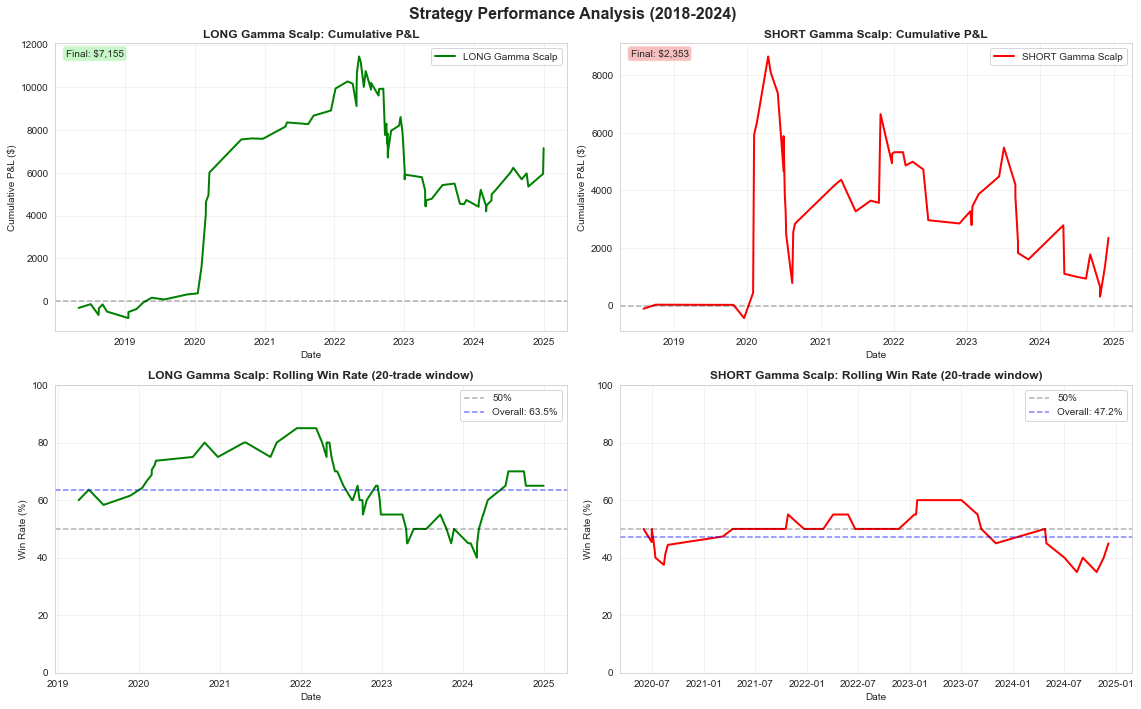

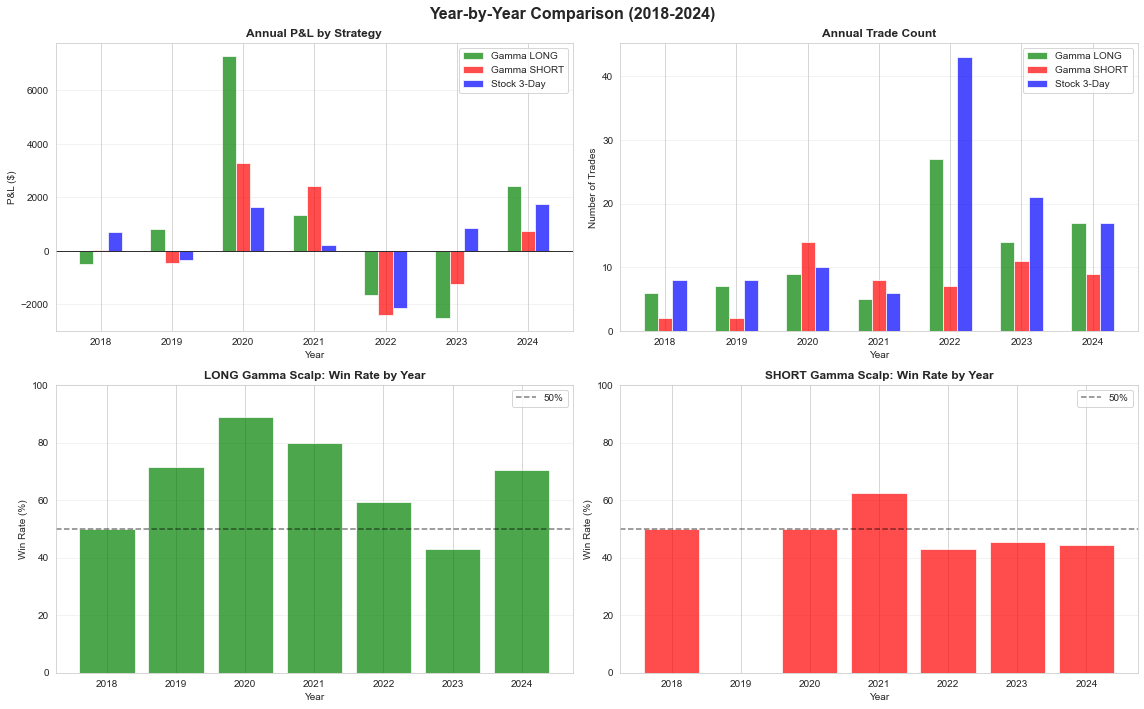


🔍 KEY INSIGHTS

✅ LONG Gamma Scalp:
   Best Year: 2020 ($7,278)
   Overall: $7,155 with 85 trades
   Avg per trade: $84

❌ SHORT Gamma Scalp:
   Worst Year: 2022 ($-2,421)
   Overall: $2,353 with 53 trades
   Avg per trade: $44

🔍 Why is SHORT underperforming?
   Exit breakdown:
     60min Max: 31 (58.5%) | Avg: $-717
     5min RSI Target (63): 22 (41.5%) | Avg: $1,118

   60min Max exits: 31 (58.5%)
   → RSI 63 target not being hit in time!
   → Consider: Wider target (60 instead of 63) or longer time limit (90 min)

✅ ANALYSIS COMPLETE


In [5]:
# ADDITIONAL ANALYSIS - Run this after the main backtest
# This provides year-by-year breakdown and visualizations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ============================================================================
# YEAR-BY-YEAR PERFORMANCE
# ============================================================================

print("\n" + "="*80)
print("📅 YEAR-BY-YEAR PERFORMANCE")
print("="*80)

# Filter to gamma scalp only
gamma = all_trades[all_trades['strategy'] == 'Streamlined Scalp (5min)'].copy()
stock = all_trades[all_trades['strategy'] == 'Stock 3-Day'].copy()

# Calculate metrics by year and direction
yearly_perf = gamma.groupby(['year', 'direction']).agg({
    'total_pnl': ['count', 'sum', lambda x: (x > 0).mean() * 100, 'mean'],
}).round(2)

yearly_perf.columns = ['Trades', 'Total_PnL', 'Win_Rate_%', 'Avg_PnL']
print("\n🎯 GAMMA SCALP BY YEAR:\n")
print(yearly_perf.to_string())

# Stock 3-day by year
stock_yearly = stock.groupby('year').agg({
    'total_pnl': ['count', 'sum', lambda x: (x > 0).mean() * 100, 'mean']
}).round(2)
stock_yearly.columns = ['Trades', 'Total_PnL', 'Win_Rate_%', 'Avg_PnL']
print("\n\n📈 STOCK 3-DAY BY YEAR:\n")
print(stock_yearly.to_string())

# ============================================================================
# CUMULATIVE P&L BY YEAR
# ============================================================================

print("\n" + "="*80)
print("📊 CUMULATIVE P&L BY STRATEGY")
print("="*80)

# Prepare data
gamma['cumulative_pnl'] = gamma.sort_values('entry_time').groupby('direction')['total_pnl'].cumsum()
stock['cumulative_pnl'] = stock.sort_values('entry_time')['total_pnl'].cumsum()

# Summary table
summary_by_year = []
for year in range(2018, 2025):
    gamma_long_yr = gamma[(gamma['year'] == year) & (gamma['direction'] == 'LONG')]
    gamma_short_yr = gamma[(gamma['year'] == year) & (gamma['direction'] == 'SHORT')]
    stock_yr = stock[stock['year'] == year]
    
    summary_by_year.append({
        'Year': year,
        'Gamma_LONG_PnL': gamma_long_yr['total_pnl'].sum() if not gamma_long_yr.empty else 0,
        'Gamma_LONG_Trades': len(gamma_long_yr),
        'Gamma_SHORT_PnL': gamma_short_yr['total_pnl'].sum() if not gamma_short_yr.empty else 0,
        'Gamma_SHORT_Trades': len(gamma_short_yr),
        'Stock_PnL': stock_yr['total_pnl'].sum() if not stock_yr.empty else 0,
        'Stock_Trades': len(stock_yr)
    })

summary_df = pd.DataFrame(summary_by_year)
print("\n")
print(summary_df.to_string(index=False))

# ============================================================================
# VISUALIZATION 1: CUMULATIVE P&L OVER TIME
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Strategy Performance Analysis (2018-2024)', fontsize=16, fontweight='bold')

# 1. Cumulative P&L - LONG Gamma
gamma_long = gamma[gamma['direction'] == 'LONG'].sort_values('entry_time')
gamma_short = gamma[gamma['direction'] == 'SHORT'].sort_values('entry_time')

axes[0, 0].plot(gamma_long['entry_time'], gamma_long['cumulative_pnl'], 
                linewidth=2, color='green', label='LONG Gamma Scalp')
axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0, 0].set_title('LONG Gamma Scalp: Cumulative P&L', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative P&L ($)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Add final value annotation
if not gamma_long.empty:
    final_pnl = gamma_long['cumulative_pnl'].iloc[-1]
    axes[0, 0].text(0.02, 0.98, f'Final: ${final_pnl:,.0f}', 
                   transform=axes[0, 0].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# 2. Cumulative P&L - SHORT Gamma
axes[0, 1].plot(gamma_short['entry_time'], gamma_short['cumulative_pnl'], 
                linewidth=2, color='red', label='SHORT Gamma Scalp')
axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0, 1].set_title('SHORT Gamma Scalp: Cumulative P&L', fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Cumulative P&L ($)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Add final value annotation
if not gamma_short.empty:
    final_pnl = gamma_short['cumulative_pnl'].iloc[-1]
    axes[0, 1].text(0.02, 0.98, f'Final: ${final_pnl:,.0f}', 
                   transform=axes[0, 1].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

# 3. Rolling Win Rate - LONG (20-trade window)
if len(gamma_long) >= 20:
    gamma_long['win'] = (gamma_long['total_pnl'] > 0).astype(int)
    gamma_long['rolling_wr'] = gamma_long['win'].rolling(20, min_periods=10).mean() * 100
    
    axes[1, 0].plot(gamma_long['entry_time'], gamma_long['rolling_wr'], 
                   linewidth=2, color='green')
    axes[1, 0].axhline(y=50, color='black', linestyle='--', alpha=0.3, label='50%')
    axes[1, 0].axhline(y=gamma_long['win'].mean() * 100, color='blue', 
                      linestyle='--', alpha=0.5, label=f"Overall: {gamma_long['win'].mean()*100:.1f}%")
    axes[1, 0].set_title('LONG Gamma Scalp: Rolling Win Rate (20-trade window)', fontweight='bold')
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Win Rate (%)')
    axes[1, 0].set_ylim(0, 100)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
else:
    axes[1, 0].text(0.5, 0.5, 'Insufficient data for rolling win rate', 
                   ha='center', va='center', transform=axes[1, 0].transAxes)

# 4. Rolling Win Rate - SHORT (20-trade window)
if len(gamma_short) >= 20:
    gamma_short['win'] = (gamma_short['total_pnl'] > 0).astype(int)
    gamma_short['rolling_wr'] = gamma_short['win'].rolling(20, min_periods=10).mean() * 100
    
    axes[1, 1].plot(gamma_short['entry_time'], gamma_short['rolling_wr'], 
                   linewidth=2, color='red')
    axes[1, 1].axhline(y=50, color='black', linestyle='--', alpha=0.3, label='50%')
    axes[1, 1].axhline(y=gamma_short['win'].mean() * 100, color='blue', 
                      linestyle='--', alpha=0.5, label=f"Overall: {gamma_short['win'].mean()*100:.1f}%")
    axes[1, 1].set_title('SHORT Gamma Scalp: Rolling Win Rate (20-trade window)', fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Win Rate (%)')
    axes[1, 1].set_ylim(0, 100)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
else:
    axes[1, 1].text(0.5, 0.5, 'Insufficient data for rolling win rate', 
                   ha='center', va='center', transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2: YEARLY COMPARISON
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Year-by-Year Comparison (2018-2024)', fontsize=16, fontweight='bold')

years = summary_df['Year']
x_pos = np.arange(len(years))

# 1. P&L by Year - Stacked
long_pnl = summary_df['Gamma_LONG_PnL']
short_pnl = summary_df['Gamma_SHORT_PnL']
stock_pnl = summary_df['Stock_PnL']

axes[0, 0].bar(x_pos - 0.2, long_pnl, width=0.2, label='Gamma LONG', color='green', alpha=0.7)
axes[0, 0].bar(x_pos, short_pnl, width=0.2, label='Gamma SHORT', color='red', alpha=0.7)
axes[0, 0].bar(x_pos + 0.2, stock_pnl, width=0.2, label='Stock 3-Day', color='blue', alpha=0.7)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('P&L ($)')
axes[0, 0].set_title('Annual P&L by Strategy', fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(years)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Trade Count by Year
long_trades = summary_df['Gamma_LONG_Trades']
short_trades = summary_df['Gamma_SHORT_Trades']
stock_trades = summary_df['Stock_Trades']

axes[0, 1].bar(x_pos - 0.2, long_trades, width=0.2, label='Gamma LONG', color='green', alpha=0.7)
axes[0, 1].bar(x_pos, short_trades, width=0.2, label='Gamma SHORT', color='red', alpha=0.7)
axes[0, 1].bar(x_pos + 0.2, stock_trades, width=0.2, label='Stock 3-Day', color='blue', alpha=0.7)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Number of Trades')
axes[0, 1].set_title('Annual Trade Count', fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(years)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Win Rate by Year - LONG
yearly_wr_long = gamma[gamma['direction'] == 'LONG'].groupby('year').apply(
    lambda x: (x['total_pnl'] > 0).mean() * 100
)
axes[1, 0].bar(yearly_wr_long.index, yearly_wr_long.values, color='green', alpha=0.7)
axes[1, 0].axhline(y=50, color='black', linestyle='--', alpha=0.5, label='50%')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Win Rate (%)')
axes[1, 0].set_title('LONG Gamma Scalp: Win Rate by Year', fontweight='bold')
axes[1, 0].set_ylim(0, 100)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Win Rate by Year - SHORT
yearly_wr_short = gamma[gamma['direction'] == 'SHORT'].groupby('year').apply(
    lambda x: (x['total_pnl'] > 0).mean() * 100
)
axes[1, 1].bar(yearly_wr_short.index, yearly_wr_short.values, color='red', alpha=0.7)
axes[1, 1].axhline(y=50, color='black', linestyle='--', alpha=0.5, label='50%')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Win Rate (%)')
axes[1, 1].set_title('SHORT Gamma Scalp: Win Rate by Year', fontweight='bold')
axes[1, 1].set_ylim(0, 100)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================================
# KEY INSIGHTS
# ============================================================================

print("\n" + "="*80)
print("🔍 KEY INSIGHTS")
print("="*80)

# Best/worst years
long_best_year = summary_df.loc[summary_df['Gamma_LONG_PnL'].idxmax(), 'Year']
long_best_pnl = summary_df['Gamma_LONG_PnL'].max()
short_worst_year = summary_df.loc[summary_df['Gamma_SHORT_PnL'].idxmin(), 'Year']
short_worst_pnl = summary_df['Gamma_SHORT_PnL'].min()

print(f"\n✅ LONG Gamma Scalp:")
print(f"   Best Year: {long_best_year} (${long_best_pnl:,.0f})")
print(f"   Overall: ${gamma_long['total_pnl'].sum():,.0f} with {len(gamma_long)} trades")
print(f"   Avg per trade: ${gamma_long['total_pnl'].mean():,.0f}")

print(f"\n❌ SHORT Gamma Scalp:")
print(f"   Worst Year: {short_worst_year} (${short_worst_pnl:,.0f})")
print(f"   Overall: ${gamma_short['total_pnl'].sum():,.0f} with {len(gamma_short)} trades")
print(f"   Avg per trade: ${gamma_short['total_pnl'].mean():,.0f}")

# Analyze why SHORT is underperforming
print(f"\n🔍 Why is SHORT underperforming?")
short_exits = gamma_short['exit_reason'].value_counts()
print(f"   Exit breakdown:")
for reason, count in short_exits.items():
    pct = count / len(gamma_short) * 100
    avg_pnl = gamma_short[gamma_short['exit_reason'] == reason]['total_pnl'].mean()
    print(f"     {reason}: {count} ({pct:.1f}%) | Avg: ${avg_pnl:,.0f}")

print(f"\n   60min Max exits: {short_exits.get('60min Max', 0)} ({short_exits.get('60min Max', 0)/len(gamma_short)*100:.1f}%)")
print(f"   → RSI 63 target not being hit in time!")
print(f"   → Consider: Wider target (60 instead of 63) or longer time limit (90 min)")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)


In [9]:
# CORRECTED HYPOTHESIS TEST: MACD Dot Requirement
# 
# FIXES:
# 1. WITHOUT DOT uses RSI 26/76 entry, 33/61 exit (tighter parameters)
# 2. WITH DOT uses RSI 30/76 entry, 37/62 exit (your proven parameters)
# 3. Proper UTC to NYSE timezone conversion (handles DST)
# 4. Trading hours: 9:45 AM - 3:00 PM ET (converted from UTC)

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import pytz

print("="*80)
print("🔬 FIXED HYPOTHESIS TEST: MACD Dot Requirement")
print("="*80)
print("\nTest Setup:")
print("  Control (WITH DOT):    RSI 30/76 → 37/62 + MACD extreme + MACD dot")
print("  Treatment (NO DOT):    RSI 26/76 → 33/61 + MACD extreme (no dot)")
print("\nTrading Hours: 9:45 AM - 3:00 PM ET (converted from UTC)")
print("="*80)

# ============================================================================
# STRATEGY 1: WITH DOT (Your proven parameters)
# ============================================================================

def backtest_with_dot(df_5min, pricer, contracts=6):
    """
    WITH DOT: Uses your proven parameters.
    Entry: RSI ≤30 (LONG), RSI ≥76 (SHORT)
    Exit: RSI ≥37 (LONG), RSI ≤62 (SHORT)
    Requires MACD momentum reversal (green/red dot)
    """
    trades = []
    dte = 3
    
    # Define ET timezone for NYSE
    et_tz = pytz.timezone('America/New_York')
    
    # Entry window in ET
    entry_start_et = pd.Timestamp('1900-01-01 09:45:00').time()
    entry_end_et = pd.Timestamp('1900-01-01 15:00:00').time()
    
    # Parameters
    LONG_RSI_ENTRY = 30
    SHORT_RSI_ENTRY = 76
    LONG_RSI_EXIT = 37
    SHORT_RSI_EXIT = 62
    MAX_HOLD_MIN = 60
    
    i = 0
    while i < len(df_5min) - 1:
        current = df_5min.iloc[i]
        entry_time = df_5min.index[i]
        
        # Convert UTC to ET
        if entry_time.tzinfo is None:
            entry_time_utc = entry_time.tz_localize('UTC')
        else:
            entry_time_utc = entry_time
        entry_time_et = entry_time_utc.tz_convert(et_tz)
        
        # Check if within trading hours (ET)
        if not (entry_start_et <= entry_time_et.time() <= entry_end_et):
            i += 1
            continue
        
        trade_direction = None
        
        # LONG: RSI ≤30 + MACD extreme + GREEN DOT
        if (current['rsi'] <= LONG_RSI_ENTRY and 
            current['macd'] < current['macd_bottom_10pct_value'] and 
            current['green_circle']):
            trade_direction = 'LONG'
        
        # SHORT: RSI ≥76 + MACD extreme + RED DOT
        elif (current['rsi'] >= SHORT_RSI_ENTRY and 
              current['macd'] > current['macd_top_10pct_value'] and 
              current['red_circle']):
            trade_direction = 'SHORT'
        
        if trade_direction:
            entry_price = current['close']
            strike = round(entry_price)
            T_entry = dte / 365.0
            
            if trade_direction == 'LONG':
                entry_opt, _, _, _, _ = pricer.calculate_call(entry_price, strike, T_entry)
            else:
                entry_opt, _, _, _, _ = pricer.calculate_put(entry_price, strike, T_entry)
            
            if entry_opt <= 0:
                i += 1
                continue
            
            # Search for exit
            max_search_index = min(i + int(MAX_HOLD_MIN / 5) + 1, len(df_5min))
            exit_time = None
            exit_reason = None
            
            for j in range(i + 1, max_search_index):
                exit_bar = df_5min.iloc[j]
                time_current = df_5min.index[j]
                
                minutes_elapsed = (time_current - entry_time).total_seconds() / 60
                days_elapsed = minutes_elapsed / (6.5 * 60)
                T_current = max((dte - days_elapsed) / 365.0, 0.0001)
                
                current_stock_price = exit_bar['close']
                
                if trade_direction == 'LONG':
                    current_opt, _, _, _, _ = pricer.calculate_call(current_stock_price, strike, T_current)
                else:
                    current_opt, _, _, _, _ = pricer.calculate_put(current_stock_price, strike, T_current)
                
                pnl_pct = ((current_opt - entry_opt) / entry_opt * 100) if entry_opt > 0 else -100
                
                # Check exits
                if trade_direction == 'LONG' and exit_bar['rsi'] >= LONG_RSI_EXIT:
                    exit_reason = 'RSI Target'
                elif trade_direction == 'SHORT' and exit_bar['rsi'] <= SHORT_RSI_EXIT:
                    exit_reason = 'RSI Target'
                elif pnl_pct <= -50:
                    exit_reason = '-50% Stop'
                
                if exit_reason:
                    exit_time = time_current
                    exit_opt = current_opt
                    i = j
                    break
            
            # 60min timeout
            if exit_time is None:
                last_idx = max_search_index - 1
                exit_time = df_5min.index[last_idx]
                minutes_elapsed = (exit_time - entry_time).total_seconds() / 60
                days_elapsed = minutes_elapsed / (6.5 * 60)
                T_current = max((dte - days_elapsed) / 365.0, 0.0001)
                exit_price_stock = df_5min.iloc[last_idx]['close']
                
                if trade_direction == 'LONG':
                    exit_opt, _, _, _, _ = pricer.calculate_call(exit_price_stock, strike, T_current)
                else:
                    exit_opt, _, _, _, _ = pricer.calculate_put(exit_price_stock, strike, T_current)
                
                exit_reason = '60min Max'
                i = last_idx
            
            if exit_time:
                pnl_per_share = exit_opt - entry_opt
                total_pnl = pnl_per_share * 100 * contracts
                
                trades.append({
                    'direction': trade_direction,
                    'entry_time': entry_time,
                    'exit_time': exit_time,
                    'total_pnl': total_pnl,
                    'exit_reason': exit_reason
                })
        
        i += 1
    
    return pd.DataFrame(trades)

# ============================================================================
# STRATEGY 2: WITHOUT DOT (Tighter parameters to test hypothesis)
# ============================================================================

def backtest_without_dot(df_5min, pricer, contracts=6):
    """
    NO DOT: Tests if extreme zones alone are sufficient.
    Entry: RSI ≤26 (LONG), RSI ≥76 (SHORT)
    Exit: RSI ≥33 (LONG), RSI ≤61 (SHORT)
    NO MACD dot requirement (just RSI + MACD extreme zones)
    
    Includes 30-min cooldown to prevent consecutive entries.
    """
    trades = []
    dte = 3
    
    # Define ET timezone
    et_tz = pytz.timezone('America/New_York')
    
    # Entry window in ET
    entry_start_et = pd.Timestamp('1900-01-01 09:45:00').time()
    entry_end_et = pd.Timestamp('1900-01-01 15:00:00').time()
    
    # Parameters (TIGHTER for hypothesis test)
    LONG_RSI_ENTRY = 26
    SHORT_RSI_ENTRY = 76
    LONG_RSI_EXIT = 33
    SHORT_RSI_EXIT = 61
    MAX_HOLD_MIN = 60
    
    # Cooldown to prevent spam entries
    last_long_entry = None
    last_short_entry = None
    COOLDOWN_MIN = 30
    
    i = 0
    while i < len(df_5min) - 1:
        current = df_5min.iloc[i]
        entry_time = df_5min.index[i]
        
        # Convert UTC to ET
        if entry_time.tzinfo is None:
            entry_time_utc = entry_time.tz_localize('UTC')
        else:
            entry_time_utc = entry_time
        entry_time_et = entry_time_utc.tz_convert(et_tz)
        
        # Check if within trading hours (ET)
        if not (entry_start_et <= entry_time_et.time() <= entry_end_et):
            i += 1
            continue
        
        trade_direction = None
        
        # Check cooldown
        long_ok = (last_long_entry is None or 
                  (entry_time - last_long_entry).total_seconds() / 60 >= COOLDOWN_MIN)
        short_ok = (last_short_entry is None or 
                   (entry_time - last_short_entry).total_seconds() / 60 >= COOLDOWN_MIN)
        
        # LONG: RSI ≤26 + MACD extreme (NO DOT!)
        if (long_ok and
            current['rsi'] <= LONG_RSI_ENTRY and 
            current['macd'] < current['macd_bottom_10pct_value']):
            trade_direction = 'LONG'
            last_long_entry = entry_time
        
        # SHORT: RSI ≥76 + MACD extreme (NO DOT!)
        elif (short_ok and
              current['rsi'] >= SHORT_RSI_ENTRY and 
              current['macd'] > current['macd_top_10pct_value']):
            trade_direction = 'SHORT'
            last_short_entry = entry_time
        
        if trade_direction:
            entry_price = current['close']
            strike = round(entry_price)
            T_entry = dte / 365.0
            
            if trade_direction == 'LONG':
                entry_opt, _, _, _, _ = pricer.calculate_call(entry_price, strike, T_entry)
            else:
                entry_opt, _, _, _, _ = pricer.calculate_put(entry_price, strike, T_entry)
            
            if entry_opt <= 0:
                i += 1
                continue
            
            # Search for exit
            max_search_index = min(i + int(MAX_HOLD_MIN / 5) + 1, len(df_5min))
            exit_time = None
            exit_reason = None
            
            for j in range(i + 1, max_search_index):
                exit_bar = df_5min.iloc[j]
                time_current = df_5min.index[j]
                
                minutes_elapsed = (time_current - entry_time).total_seconds() / 60
                days_elapsed = minutes_elapsed / (6.5 * 60)
                T_current = max((dte - days_elapsed) / 365.0, 0.0001)
                
                current_stock_price = exit_bar['close']
                
                if trade_direction == 'LONG':
                    current_opt, _, _, _, _ = pricer.calculate_call(current_stock_price, strike, T_current)
                else:
                    current_opt, _, _, _, _ = pricer.calculate_put(current_stock_price, strike, T_current)
                
                pnl_pct = ((current_opt - entry_opt) / entry_opt * 100) if entry_opt > 0 else -100
                
                # Check exits
                if trade_direction == 'LONG' and exit_bar['rsi'] >= LONG_RSI_EXIT:
                    exit_reason = 'RSI Target'
                elif trade_direction == 'SHORT' and exit_bar['rsi'] <= SHORT_RSI_EXIT:
                    exit_reason = 'RSI Target'
                elif pnl_pct <= -50:
                    exit_reason = '-50% Stop'
                
                if exit_reason:
                    exit_time = time_current
                    exit_opt = current_opt
                    i = j
                    break
            
            # 60min timeout
            if exit_time is None:
                last_idx = max_search_index - 1
                exit_time = df_5min.index[last_idx]
                minutes_elapsed = (exit_time - entry_time).total_seconds() / 60
                days_elapsed = minutes_elapsed / (6.5 * 60)
                T_current = max((dte - days_elapsed) / 365.0, 0.0001)
                exit_price_stock = df_5min.iloc[last_idx]['close']
                
                if trade_direction == 'LONG':
                    exit_opt, _, _, _, _ = pricer.calculate_call(exit_price_stock, strike, T_current)
                else:
                    exit_opt, _, _, _, _ = pricer.calculate_put(exit_price_stock, strike, T_current)
                
                exit_reason = '60min Max'
                i = last_idx
            
            if exit_time:
                pnl_per_share = exit_opt - entry_opt
                total_pnl = pnl_per_share * 100 * contracts
                
                trades.append({
                    'direction': trade_direction,
                    'entry_time': entry_time,
                    'exit_time': exit_time,
                    'total_pnl': total_pnl,
                    'exit_reason': exit_reason
                })
        
        i += 1
    
    return pd.DataFrame(trades)

# ============================================================================
# RUN HYPOTHESIS TEST
# ============================================================================

print("\n🔬 Running hypothesis test...\n")

control_results = []
treatment_results = []

for year in range(2018, 2025):
    try:
        df_year = df_5min.loc[str(year)].copy()
        if not df_year.empty:
            print(f"Processing {year}...")
            
            # Control (WITH DOT)
            ctrl = backtest_with_dot(df_year, pricer)
            if not ctrl.empty:
                ctrl['year'] = year
                control_results.append(ctrl)
            
            # Treatment (NO DOT)
            treat = backtest_without_dot(df_year, pricer)
            if not treat.empty:
                treat['year'] = year
                treatment_results.append(treat)
    except Exception as e:
        print(f"Error in {year}: {e}")
        continue

control_all = pd.concat(control_results, ignore_index=True) if control_results else pd.DataFrame()
treatment_all = pd.concat(treatment_results, ignore_index=True) if treatment_results else pd.DataFrame()

# ============================================================================
# RESULTS
# ============================================================================

print("\n" + "="*80)
print("📊 HYPOTHESIS TEST RESULTS")
print("="*80)

def analyze(df, label):
    if df.empty:
        print(f"\n{label}: No trades")
        return
    
    long = df[df['direction'] == 'LONG']
    short = df[df['direction'] == 'SHORT']
    
    print(f"\n{label}:")
    print(f"  Total Trades: {len(df)} (LONG: {len(long)}, SHORT: {len(short)})")
    print(f"  Total P&L: ${df['total_pnl'].sum():,.2f}")
    print(f"  Win Rate: {(df['total_pnl'] > 0).mean() * 100:.1f}%")
    print(f"  Avg per trade: ${df['total_pnl'].mean():.2f}")
    
    if not long.empty:
        print(f"\n  LONG:")
        print(f"    P&L: ${long['total_pnl'].sum():,.2f}")
        print(f"    Win Rate: {(long['total_pnl'] > 0).mean() * 100:.1f}%")
        print(f"    Avg: ${long['total_pnl'].mean():.2f}")
    
    if not short.empty:
        print(f"\n  SHORT:")
        print(f"    P&L: ${short['total_pnl'].sum():,.2f}")
        print(f"    Win Rate: {(short['total_pnl'] > 0).mean() * 100:.1f}%")
        print(f"    Avg: ${short['total_pnl'].mean():.2f}")

analyze(control_all, "CONTROL (WITH DOT: 30/76 → 37/62)")
analyze(treatment_all, "TREATMENT (NO DOT: 26/76 → 33/61)")

# Comparison
if not control_all.empty and not treatment_all.empty:
    print("\n" + "="*80)
    print("📊 COMPARISON")
    print("="*80)
    
    ctrl_pnl = control_all['total_pnl'].sum()
    treat_pnl = treatment_all['total_pnl'].sum()
    diff = treat_pnl - ctrl_pnl
    
    print(f"\nTrade Count:")
    print(f"  WITH DOT:  {len(control_all)}")
    print(f"  NO DOT:    {len(treatment_all)}")
    print(f"  Difference: {len(treatment_all) - len(control_all):+d}")
    
    print(f"\nTotal P&L:")
    print(f"  WITH DOT:  ${ctrl_pnl:,.2f}")
    print(f"  NO DOT:    ${treat_pnl:,.2f}")
    print(f"  Difference: ${diff:+,.2f}")
    
    print(f"\nAvg P&L per Trade:")
    print(f"  WITH DOT:  ${control_all['total_pnl'].mean():.2f}")
    print(f"  NO DOT:    ${treatment_all['total_pnl'].mean():.2f}")
    
    print("\n" + "="*80)
    print("🎯 CONCLUSION")
    print("="*80)
    
    if abs(diff) < max(abs(ctrl_pnl), abs(treat_pnl)) * 0.15:
        print("\n⚖️ SIMILAR PERFORMANCE (within 15%)")
        print("   The MACD dot doesn't significantly impact results")
        print("   Choose based on preference:")
        print("     • WITH DOT: Fewer trades, momentum confirmation")
        print("     • NO DOT: More trades, simpler logic")
    elif treat_pnl > ctrl_pnl:
        print(f"\n✅ NO DOT WINS by ${diff:,.2f}")
        print("   The MACD dot is NOT necessary!")
        print("   Being in extreme zones (RSI + MACD) is sufficient")
        print("   📊 Recommendation: Remove dot requirement")
    else:
        print(f"\n❌ WITH DOT WINS by ${-diff:,.2f}")
        print("   The MACD momentum reversal (dot) IS valuable!")
        print("   It filters out premature entries and improves timing")
        print("   📊 Recommendation: Keep the dot requirement")

print("\n" + "="*80)
print("✅ TEST COMPLETE")
print("="*80)

🔬 FIXED HYPOTHESIS TEST: MACD Dot Requirement

Test Setup:
  Control (WITH DOT):    RSI 30/76 → 37/62 + MACD extreme + MACD dot
  Treatment (NO DOT):    RSI 26/76 → 33/61 + MACD extreme (no dot)

Trading Hours: 9:45 AM - 3:00 PM ET (converted from UTC)

🔬 Running hypothesis test...

Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...

📊 HYPOTHESIS TEST RESULTS

CONTROL (WITH DOT: 30/76 → 37/62):
  Total Trades: 138 (LONG: 85, SHORT: 53)
  Total P&L: $9,507.63
  Win Rate: 57.2%
  Avg per trade: $68.90

  LONG:
    P&L: $7,155.12
    Win Rate: 63.5%
    Avg: $84.18

  SHORT:
    P&L: $2,352.51
    Win Rate: 47.2%
    Avg: $44.39

TREATMENT (NO DOT: 26/76 → 33/61):
  Total Trades: 1474 (LONG: 759, SHORT: 715)
  Total P&L: $-53,243.60
  Win Rate: 53.5%
  Avg per trade: $-36.12

  LONG:
    P&L: $43,596.59
    Win Rate: 58.2%
    Avg: $57.44

  SHORT:
    P&L: $-96,840.20
    Win Rate: 48.4%
    Avg: $-135.44

